<a href="https://colab.research.google.com/github/piaseckazaneta/Python/blob/main/Retail_Site_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install libraries

In [2]:
!pip install -q geopandas osmnx h3 shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.8 MB/s eta 0:00:00


Download city boundaries

<Axes: >

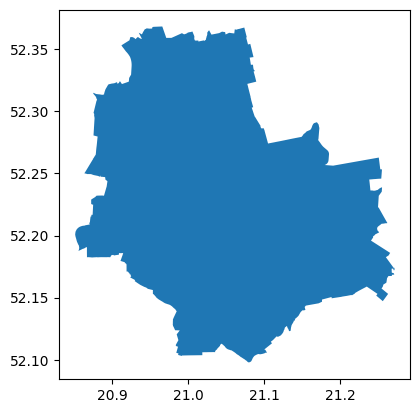

In [3]:
import osmnx as ox

place = "Warsaw, Poland"
city = ox.geocode_to_gdf(place)
city.plot()

Code one hexagon

In [4]:
import h3

lat = 52.408
lng = 16.934
my_hex = h3.latlng_to_cell(lat, lng, res=9)
print(my_hex)
corners = h3.cell_to_boundary(my_hex)
print(corners)




891e24a1253ffff
((52.40892928045555, 16.932062623468376), (52.40728019897854, 16.93210158365773), (52.40653435875778, 16.93467577857375), (52.4074375806877, 16.937211097379173), (52.40908666902555, 16.937172261902163), (52.409832528574206, 16.934597982906187))


Cover a city by hexagons

In [5]:
from shapely.geometry import MultiPolygon, Polygon
import geopandas as gpd

In [6]:
geom = city.geometry.iloc[0]
polys = [geom] if isinstance(geom, Polygon) else list(geom.geoms)
hex_ids = set()

for p in polys:
  outer = [(lat, lng) for lng, lat in p.exterior.coords]
  holes = [[(lat, lng) for lng, lat in hole.coords] for hole in p.interiors]
  h3_poly = h3.LatLngPoly(outer, holes)
  cells = h3.polygon_to_cells(h3_poly, res=9)
  hex_ids.update(cells)

To co niżej, tylko uproszczone, bez list comprehension:

1. Tworzymy puste pudełko na narysowane heksagony
hex_geoms = []

2. Wyciągamy po jednym kodzie heksagonu z naszego worka

    for hid in hex_ids:
    
    Zapytaj Ubera: "Gdzie są wierzchołki tego heksagonu?"

    Uber oddaje wierzchołki jako (lat, lng)
    wierzcholki_ubera = h3.cell_to_boundary(hid)
    
    Odwracamy współrzędne każdego wierzchołka na styl mapowy (lng, lat)

    wierzcholki_gis = []
    for lat, lng in wierzcholki_ubera:
        wierzcholki_gis.append((lng, lat))
        
    Zrób z tych punktów prawdziwy kształt (Polygon)
    ksztalt = Polygon(wierzcholki_gis)
    
    Włóż gotowy kształt do pudełka
    hex_geoms.append(ksztalt)

<Axes: >

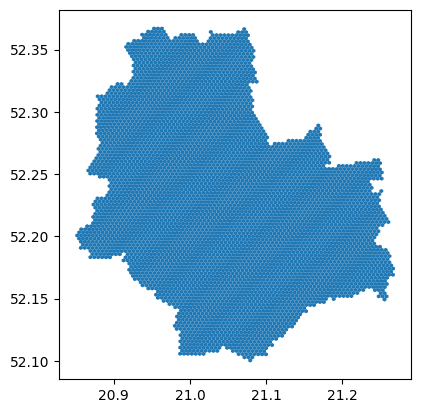

In [10]:
hex_geoms = [Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(hid)]) for hid in hex_ids]
grid = gpd.GeoDataFrame({'hex_id': list(hex_ids), 'geometry': hex_geoms}, crs="EPSG:4326")
grid.plot()